## Data Preprocessing in Python

Data preprocessing is the first step in any data analysis or machine learning pipeline. It involves cleaning, transforming and organizing raw data to ensure it is accurate, consistent and ready for modeling. It has a big impact on model building such as:

Clean and well-structured data allows models to learn meaningful patterns rather than noise.

Properly processed data prevents misleading inputs, leading to more reliable predictions.

Organized data makes it simpler to create useful inputs for the model, enhancing model performance.

Organized data supports better Exploratory Data Analysis (EDA), making patterns and trends more interpretable.
data_cleaning

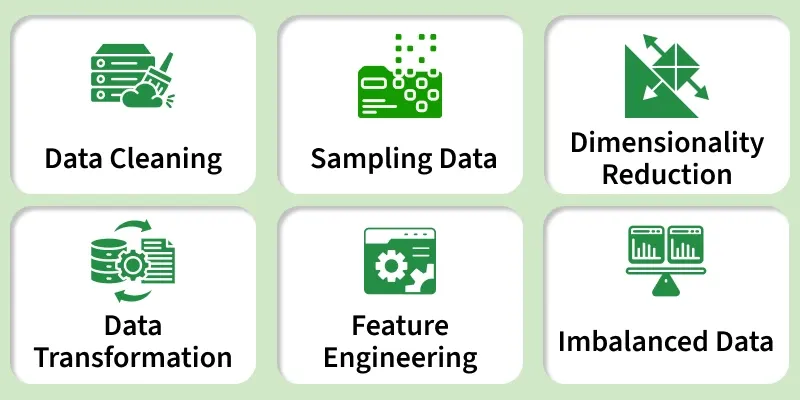

## Step 1: Import Libraries and Load Dataset

We prepare the environment with libraries like pandas, numpy, scikit learn, matplotlib and seaborn for data manipulation, numerical operations, visualization and scaling. Load the dataset for preprocessing.

## Step 2: Inspect Data Structure and Check Missing Values


We understand dataset size, data types and identify any incomplete (missing) data that needs handling.


df.info(): Prints concise summary including count of non-null entries and data type of each column.

df.isnull().sum(): Returns the number of missing values per column.

## Step 3: Statistical Summary and Visualizing Outliers


Get numeric summaries like mean, median, min/max and detect unusual points (outliers). Outliers can skew models if not handled.



df.describe(): Computes count, mean, std deviation, min/max and quartiles for numerical columns.

Boxplots: Visualize spread and detect outliers using matplotlib’s boxplot().

## Step 4: Remove Outliers Using the Interquartile Range (IQR) Method

Remove extreme values beyond a reasonable range to improve model robustness.



IQR = Q3 (75th percentile) – Q1 (25th percentile).

Values below Q1 - 1.5IQR or above Q3 + 1.5IQR are outliers.

Calculate lower and upper bounds for each column separately.

Filter data points to keep only those within bounds.

## Step 5: Correlation Analysis

Understand relationships between features and the target variable (Outcome). Correlation helps gauge feature importance.

df.corr(): Computes pairwise correlation coefficients between columns.

Heatmap via seaborn visualizes correlation matrix clearly.

Sorting correlations with corr['Outcome'].sort_values() highlights features most correlated with the target.

## Step 6: Visualize Target Variable Distribution

Check if target classes (Diabetes vs Not Diabetes) are balanced, affecting model training and evaluation.

plt.pie(): Pie chart to display proportion of each class in the target variable 'Outcome'.

plt.pie(clean_df['Outcome'].value_counts(),

## Step 7: Separate Features and Target Variable

Prepare independent variables (features) and dependent variable (target) separately for modeling.

df.drop(columns=[...]): Drops the target column from features.

Direct column selection df['Outcome'] selects target column.


## Advantages

Cleans and organizes raw data for better analysis.

Removes noise and irrelevant data, leading to more precise predictions.

Handles outliers and redundant features, which reduces overfitting.

Scaling data helps models train faster by reducing computation time.

Converts data into formats suitable for machine learning models.

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('diabetes.csv')
df.describe()



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:

# 2
df.info()
print(df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome    

C:\Users\vamse\AppData\Local\Temp\ipykernel_8328\1142893509.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df[col], vert=False)
C:\Users\vamse\AppData\Local\Temp\ipykernel_8328\1142893509.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df[col], vert=False)
C:\Users\vamse\AppData\Local\Temp\ipykernel_8328\1142893509.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df[col], vert=False)
C:\Users\vamse\AppData\Local\Temp\ipykernel_8328\1142893509.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} ins

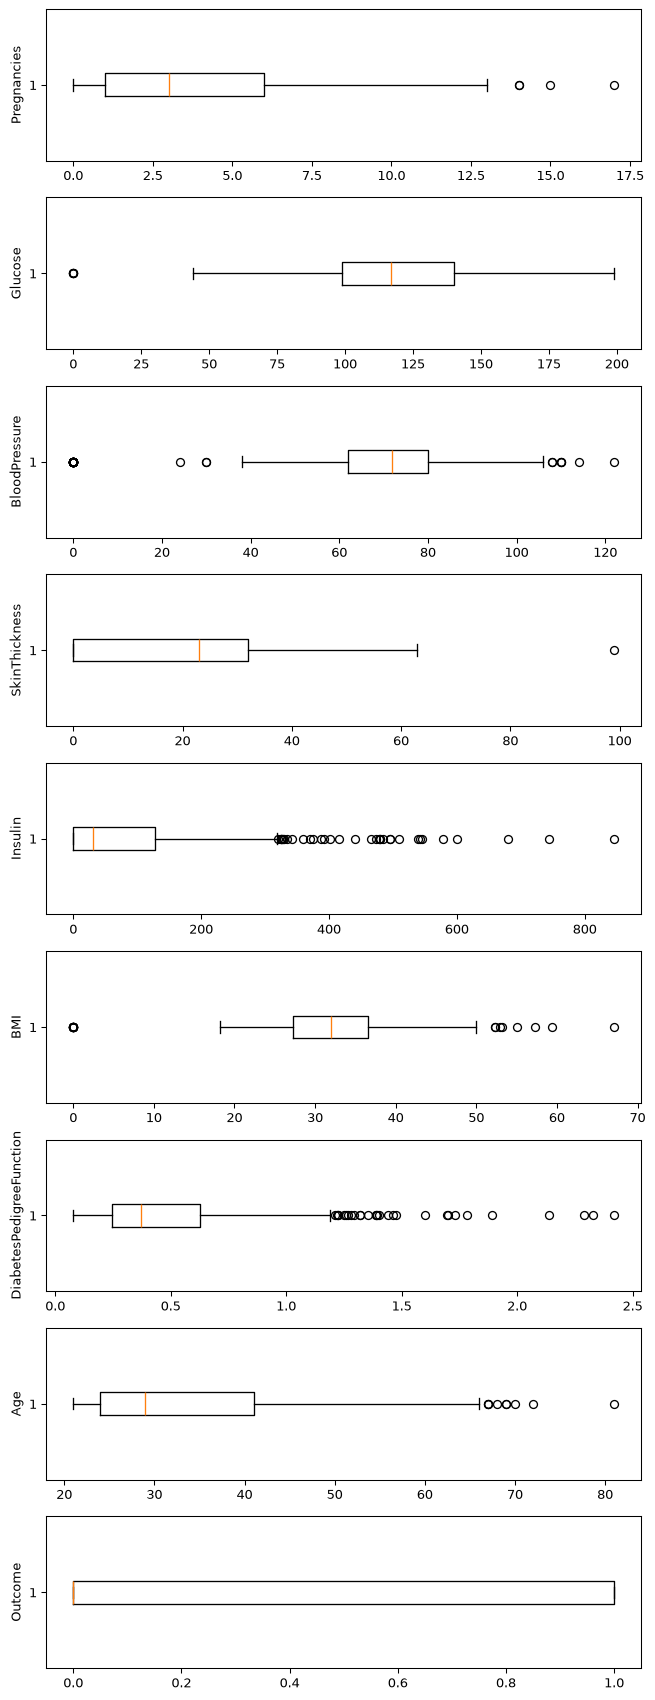

In [5]:


# 3
df.describe()

fig, axs = plt.subplots(len(df.columns), 1, figsize=(7, 18), dpi=95)
for i, col in enumerate(df.columns):
    axs[i].boxplot(df[col], vert=False)
    axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()


In [ ]:

# 4
q1, q3 = np.percentile(df['Insulin'], [25, 75])
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
clean_df = df[(df['Insulin'] >= lower) & (df['Insulin'] <= upper)]
print(f"Original DataFrame shape: {df.shape}")
print(f"Cleaned DataFrame shape: {clean_df.shape}")
print(clean_df.describe())


Original DataFrame shape: (768, 9)
Cleaned DataFrame shape: (734, 9)
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcom

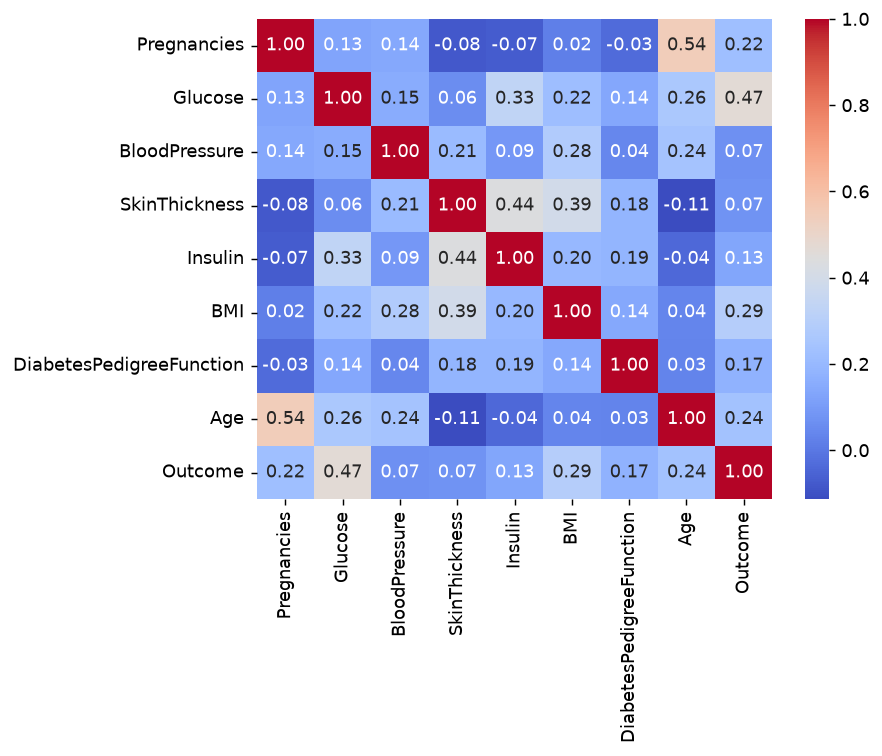

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [8]:

# 5
corr = df.corr()
plt.figure(dpi=130)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

print(corr['Outcome'].sort_values(ascending=False))


In [ ]:

# 6
plt.pie(clean_df['Outcome'].value_counts(),
        labels=['Diabetes', 'Not Diabetes'],
        autopct='%.f%%', shadow=True)
plt.title('Outcome Proportionality')       
plt.show()


In [ ]:

# 7
X = df.drop(columns=['Outcome'])
y = df['Outcome']


In [ ]:

# 8 
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)
print(X_normalized[:5])